# Задание 2: Однофакторный дисперсионный анализ (One-way ANOVA)

## Модель однофакторного ANOVA:

Фактор: этническая/национальная группа (race/ethnicity)

Зависимая переменная: суммарный балл за все три экзамена

$\qquad Y_{ij} = \mu_i + \varepsilon_{ij}$

где:
- $Y_{ij}$ - j-е наблюдение в i-й группе
- $\mu_i$ - среднее значение в i-й группе
- $E_{ij} \sim N(0, \sigma^2)$ - случайная ошибка

## Гипотезы:

- H0: $\mu_1 = \mu_2 = ... = \mu_k$ (средние баллы во всех группах равны)

- H1: хотя бы одно среднее отличается

## Разложение дисперсии:

$\qquad TSS = BSS + WSS$

где:
- TSS (Total Sum of Squares) - общая сумма квадратов
- BSS (Between-group Sum of Squares) - межгрупповая сумма квадратов
- WSS (Within-group Sum of Squares) - внутригрупповая сумма квадратов

$\qquad TSS = \sum_{i=1}^k \sum_{j=1}^{n_i} (Y_{ij} - \bar{Y})^2$

$\qquad BSS = \sum_{i=1}^k n_i (\mu_i - \bar{Y})^2$

$\qquad WSS = \sum_{i=1}^k \sum_{j=1}^{n_i} (Y_{ij} - \mu_i)^2$

## F-статистика:

$\qquad F = \frac{MSB}{MSW} = \frac{BSS/(k-1)}{WSS/(n-k)}$

где:
- $k$ - число групп
- $n$ - общее число наблюдений
- MSB (Mean Square Between) - межгрупповая дисперсия
- MSW (Mean Square Within) - внутригрупповая дисперсия


## Импорты и константы


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

ALPHA = 0.05


## Подготовка данных


In [35]:
df = pd.read_csv('exams_dataset.csv')
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']

group_stats = df.groupby('race/ethnicity')['total_score'].describe()
print(f"число наблюдений: {len(df)}")
print(group_stats)

groups = df['race/ethnicity'].unique()


число наблюдений: 1000
                count        mean        std    min    25%    50%    75%  \
race/ethnicity                                                             
group A          77.0  191.662338  46.131851   68.0  158.0  193.0  223.0   
group B         204.0  195.063725  44.464973   82.0  166.0  196.0  228.0   
group C         324.0  194.981481  46.531520   35.0  166.0  195.0  228.5   
group D         261.0  209.536398  42.850227   99.0  176.0  210.0  240.0   
group E         134.0  223.805970  40.071830  127.0  196.0  225.0  255.0   

                  max  
race/ethnicity         
group A         295.0  
group B         300.0  
group C         299.0  
group D         300.0  
group E         300.0  


## Визуализация данных

средние значения по группам
group A: 191.662 (n = 77)
group B: 195.064 (n = 204)
group C: 194.981 (n = 324)
group D: 209.536 (n = 261)
group E: 223.806 (n = 134)


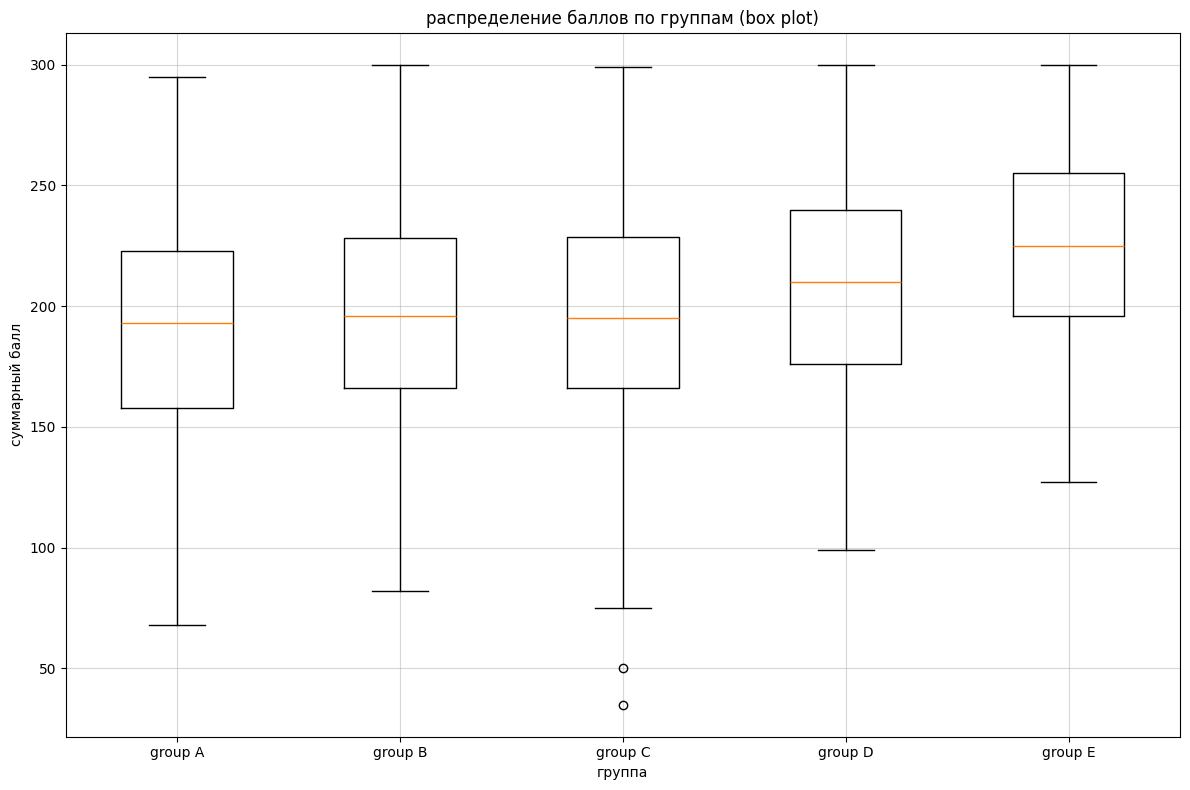

In [36]:
print("средние значения по группам")
group_means = df.groupby('race/ethnicity')['total_score'].mean().sort_index()
for group, mean_val in group_means.items():
    n_group = len(df[df['race/ethnicity'] == group])
    print(f"{group}: {mean_val:.3f} (n = {n_group})")

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.boxplot([df[df['race/ethnicity'] == group]['total_score'].values for group in sorted(groups)], tick_labels=sorted(groups))
ax.set_xlabel('группа')
ax.set_ylabel('суммарный балл')
ax.set_title('распределение баллов по группам (box plot)')
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


## Реализация однофакторного ANOVA


In [ ]:
# one-way analysis of variance
class OneWayANOVA:
    def __init__(self) -> None:
        self.groups: list[str] = []
        self.group_data: dict[str, np.ndarray] = {}
        self.y_bar: float = 0.0
        self.y_bar_i: dict[str, float] = {}
        self.BSS: float = 0.0
        self.WSS: float = 0.0
        self.F_stat: float = 0.0
        self.p_value: float = 0.0

    def fit(self, data: pd.DataFrame, group_col: str, value_col: str) -> 'OneWayANOVA':
        self.groups = sorted(data[group_col].unique())
        for group in self.groups:
            group_values: np.ndarray = data[data[group_col] == group][value_col].to_numpy()
            self.group_data[group] = group_values
            self.y_bar_i[group] = float(np.mean(group_values))
        # Общее среднее
        self.y_bar = data[value_col].mean()
        # Вычисляем суммы квадратов
        self._compute_sum_of_squares()
        # Вычисляем средние квадраты и F-статистику
        k = len(self.groups)
        n = data[value_col].notna().sum()
        df_between = k - 1
        df_within = n - k
        MSB = self.BSS / df_between
        MSW = self.WSS / df_within
        self.F_stat = MSB / MSW
        self.p_value = float(1 - stats.f.cdf(self.F_stat, df_between, df_within))
        return self

    def _compute_sum_of_squares(self) -> None:
        assert self.groups is not None and self.group_data is not None and self.y_bar_i is not None
        # Between-group Sum of Squares (BSS)
        self.BSS = 0.0
        for group in self.groups:
            n_i = len(self.group_data[group])
            y_bar_i = self.y_bar_i[group]
            self.BSS += n_i * (y_bar_i - self.y_bar) ** 2
        # Within-group Sum of Squares (WSS)
        self.WSS = 0.0
        for group in self.groups:
            group_values = self.group_data[group]
            y_bar_i = self.y_bar_i[group]
            self.WSS += float(np.sum((group_values - y_bar_i) ** 2))

    def effect_size(self) -> float:
        assert self.groups is not None and self.group_data is not None
        # η^2 = BSS / TSS
        TSS = self.BSS + self.WSS
        eta_squared = self.BSS / TSS
        return eta_squared

    def test(self) -> float:
        assert self.groups is not None and self.group_data is not None
        k = len(self.groups)
        n = sum(len(data) for data in self.group_data.values())
        df_between = k - 1
        df_within = n - k
        F_crit = stats.f.ppf(1 - ALPHA, df_between, df_within)
        print("=" * 90)
        print(f"Уровень значимости: ALPHA = {ALPHA}")
        print(f"F-статистика: {self.F_stat:.3f}")
        print(f"Критическое значение F({df_between}, {df_within}, ALPHA = {ALPHA}): {F_crit:.3f}")
        print(f"p-value: {self.p_value:.6e}")
        print(f"=" * 90)
        assert self.p_value < ALPHA, "Должны отвергать H0"
        print("Средние баллы в разных этнических группах СТАТИСТИЧЕСКИ РАЗЛИЧАЮТСЯ")
        # Величина эффекта
        eta2 = self.effect_size()
        return eta2
 

## Применение


In [41]:
anova = OneWayANOVA()
anova.fit(df, group_col='race/ethnicity', value_col='total_score')
eta2 = anova.test()
print(f"Доля вариации зависящая от фактора: {eta2:.6f}")


Уровень значимости: ALPHA = 0.05
F-статистика: 14.311
Критическое значение F(4, 995, ALPHA = 0.05): 2.381
p-value: 2.303324e-11
Средние баллы в разных этнических группах СТАТИСТИЧЕСКИ РАЗЛИЧАЮТСЯ
Доля вариации зависящая от фактора: 0.054401


## Сравнение с готовой реализацией (scipy.stats)

In [39]:
# Подготавливаем данные
group_samples = [anova.group_data[group] for group in anova.groups]

# Выполняем ANOVA
F_scipy, p_scipy = f_oneway(*group_samples)

print("=" * 90)
print(f"{'Метрика':<30} {'Наша реализация':>20} {'scipy.stats':>20} {'Разница':>15}")
print("=" * 90)
print(f"{'F-статистика':<35} {anova.F_stat:<24.3f} {F_scipy:<19.3f} {abs(anova.F_stat - F_scipy):<20.2e}")
print(f"{'p-value':<35} {anova.p_value:<24.3f} {p_scipy:<19.3f} {abs(anova.p_value - p_scipy):<20.2e}")
print("=" * 90)

assert np.isclose(anova.F_stat, F_scipy) and np.isclose(anova.p_value, p_scipy)
print("Наша реализация совпадает с scipy.stats.f_oneway")


Метрика                             Наша реализация          scipy.stats         Разница
F-статистика                        14.311                   14.311              1.78e-15            
p-value                             0.000                    0.000               1.82e-17            
Наша реализация совпадает с scipy.stats.f_oneway


## Итоговые выводы

### Результаты однофакторного дисперсионного анализа:

#### 1. Гипотеза:
- H0: Средние суммарные баллы одинаковы во всех этнических группах
- H1: Хотя бы одна группа имеет отличающееся среднее

#### 2. Результаты теста:
- F-статистика: указывает на силу различий между группами
- p-value: вероятность получить такие данные при условии, что H0 верна

#### 3. Величина эффекта:
- eta2 (eta-squared, доля вариации, объясняемая фактором) = 0.054

### Практические выводы:
- Исходя из результатов теста и значения eta2 этническая принадлежность показывает небольшую связь с академическими результатами в данной выборке.
